## Step 2: Balanced Dataset Creation

The structured dataset exhibits class imbalance, with a significantly higher number of normal cases compared to pneumonia cases.

Such imbalance can lead to:

* Biased model predictions toward the majority class
* Poor recall for pneumonia detection
* Misleading accuracy metrics

The objective of this step is to create a balanced dataset to ensure fair model training and improved sensitivity to pneumonia cases.

This is achieved by:

* Separating positive and negative samples
* Randomly sampling from the majority class
* Creating a dataset with equal representation of both classes


In [41]:
# Load structured dataset from previous step
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/sairasagnak/grouped-data/grouped_data.csv")

print(df.shape)
df.head()

(26684, 8)


,patientId,Target,class,age,sex,position,image_path,mask_path
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0,No Lung Opacity / Not Normal,51,F,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
1,000924cf-0f8d-42bd-9158-1af53881a557,0,Normal,19,F,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
2,000db696-cf54-4385-b10b-6b16fbb3f985,1,Lung Opacity,25,F,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
3,000fe35a-2649-43d4-b027-e67796d412e0,1,Lung Opacity,40,M,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1,Lung Opacity,57,M,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...


In [42]:
# Fix image and mask paths for Kaggle dataset

import os

# Correct base directory (based on your dataset structure)
DATA_DIR = "/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset"

# Define image and mask folders
IMAGE_DIR = os.path.join(DATA_DIR, "Training", "Images")
MASK_DIR = os.path.join(DATA_DIR, "Training", "Masks")

# Rebuild paths using patientId
df['image_path'] = df['patientId'].apply(lambda x: os.path.join(IMAGE_DIR, x + ".png"))
df['mask_path'] = df['patientId'].apply(lambda x: os.path.join(MASK_DIR, x + ".png"))

# Verify paths
print("Sample image path:", df['image_path'].iloc[0])
print("Exists:", os.path.exists(df['image_path'].iloc[0]))

Sample image path: /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Images/0004cfab-14fd-4e49-80ba-63a80b6bddd6.png
Exists: True


In [43]:
# Check original class distribution
df['Target'].value_counts()

Target
0    20672
1     6012
Name: count, dtype: int64

In [44]:
# Separate positive and negative samples
df_pos = df[df['Target'] == 1]
df_neg = df[df['Target'] == 0]

print("Positive samples:", len(df_pos))
print("Negative samples:", len(df_neg))

Positive samples: 6012
Negative samples: 20672


In [45]:
# Sample equal number of negative samples
df_neg_sampled = df_neg.sample(n=len(df_pos), random_state=42)

# Combine and shuffle
balanced_df = pd.concat([df_pos, df_neg_sampled]) \
                .sample(frac=1, random_state=42) \
                .reset_index(drop=True)

print("Balanced dataset shape:", balanced_df.shape)

Balanced dataset shape: (12024, 8)


In [46]:
balanced_df['Target'].value_counts()

Target
1    6012
0    6012
Name: count, dtype: int64

In [47]:
# Save for next steps
balanced_df.to_csv("balanced_data.csv", index=False)

print("Saved balanced_data.csv")

Saved balanced_data.csv


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

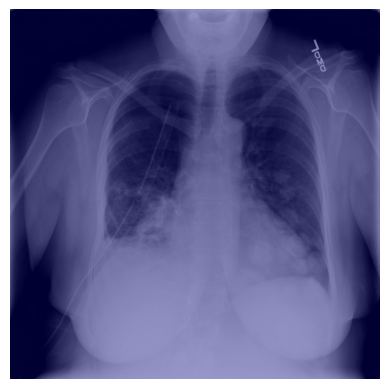

In [48]:
#Quick Visual Check
import cv2
import matplotlib.pyplot as plt
import os

row = df.iloc[0]

img = cv2.imread(row['image_path'], 0)
mask = cv2.imread(row['mask_path'], 0)

plt.imshow(img, cmap='gray')
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.axis('off')

## Step 2: Observations

* The original dataset exhibited a clear class imbalance, with normal cases significantly outnumbering pneumonia cases (20672 vs 6012).
* After applying random undersampling, a balanced dataset was created with equal representation of both classes (6012 each).
* The total dataset size reduced from 26684 to 12024 samples, indicating a trade-off between dataset size and class balance.
* Balancing ensures that the model does not become biased toward the majority class and improves its ability to detect pneumonia cases.
* However, undersampling may discard useful information from normal cases, which could affect generalization in real-world scenarios.

These observations highlight the importance of handling class imbalance and justify further comparison between balanced and imbalanced training approaches.
